<a href="https://colab.research.google.com/github/syedahijabzahra/DevelopersHub-AI-ML-Internship/blob/main/Phase_2/BERT_News_Classifier/bert_news_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U datasets torchvision --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1

GPU Available: True


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.344455,0.326914,0.893000,0.892236
2,0.182419,0.304037,0.913000,0.913095


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.182419,0.304037,2,0.913000,0.913095



=== Final Evaluation ===
Accuracy: 0.9130
F1 Score: 0.9131


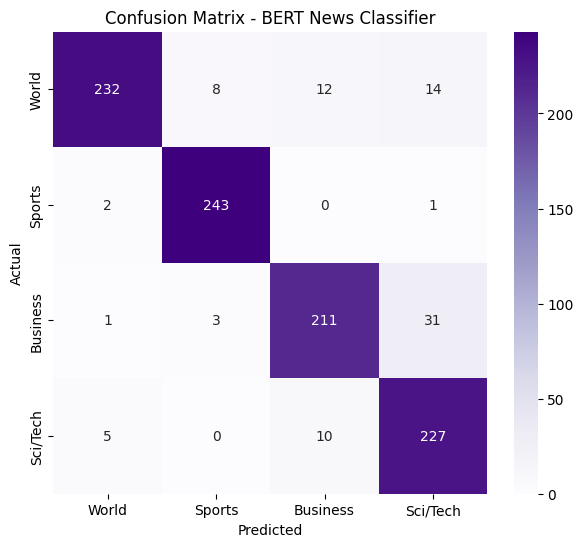


=== Sample Predictions ===
Text: indian board plans own telecast of australia series the indian cricket board sai...
Predicted: Sports | Actual: Sports

Text: stocks higher on drop in jobless claims a sharp drop in initial unemployment cla...
Predicted: Business | Actual: Business

Text: nuggets 112, raptors 106 carmelo anthony scored 30 points and kenyon martin adde...
Predicted: Sports | Actual: Sports

Text: stocks higher on drop in jobless claims a sharp drop in initial unemployment cla...
Predicted: Business | Actual: Business

Text: review : ' half - life 2 ' a tech masterpiece ( ap ) ap - it ' s been six years ...
Predicted: Sci/Tech | Actual: Sci/Tech



In [2]:
# News Topic Classifier using BERT
# Dataset: AG News (Hugging Face)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("GPU Available:", torch.cuda.is_available())

# Load AG News dataset
dataset = load_dataset("fancyzhx/ag_news")
print(dataset)

# Label names
label_names = ['World', 'Sports', 'Business', 'Sci/Tech']

# Use a subset for faster training
train_dataset = dataset['train'].shuffle(seed=42).select(range(4000))
test_dataset = dataset['test'].shuffle(seed=42).select(range(1000))

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize function
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Load model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=4)

# Metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {'accuracy': acc, 'f1': f1}

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    report_to="none"
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Train
trainer.train()

# Evaluate
results = trainer.evaluate()
print("\n=== Final Evaluation ===")
print(f"Accuracy: {results['eval_accuracy']:.4f}")
print(f"F1 Score: {results['eval_f1']:.4f}")

# Predictions for confusion matrix
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix - BERT News Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Sample predictions
print("\n=== Sample Predictions ===")
for i in range(5):
    text = test_dataset[i]['input_ids']
    decoded = tokenizer.decode(text, skip_special_tokens=True)
    pred_label = label_names[preds[i]]
    true_label = label_names[labels[i]]
    print(f"Text: {decoded[:80]}...")
    print(f"Predicted: {pred_label} | Actual: {true_label}\n")